# From Prompts to Harnesses

For a few years the advice for getting more out of a language model was "write a better prompt". It worked, up to a point. Then the interesting progress moved *around* the model: tools it can call, a loop that runs them, a budget for what it sees, checks that run outside it. That surrounding machinery has a name now, the **harness**, and designing it has become a discipline, **harness engineering**.

In this notebook we ask one factual question three ways: with a bare prompt, with a better prompt, and with a small harness you write yourself. Same model every time, the real `claude-opus-5` behind the official Anthropic SDK. Only the machinery around it changes, and so does the answer.

**What you will learn**

- Why prompt engineering hit a ceiling, and what came after it (a timeline with dates)
- What a harness is, in three definitions and one metaphor
- How to call a Claude model from Python and read what it cost, in tokens and in dollars
- How to give the model two tools and write the loop that runs them, in about forty lines, with nothing hidden
- How the same question comes out three ways, and what each way costs
- That the SDK ships the same loop, and how to use it in ten lines
- The eight pieces of a harness and where each one lives in this module

## How to run this notebook

You can run this notebook in two ways:

- **Locally with Jupyter:** open it in Jupyter Notebook, JupyterLab or VS Code and run the cells top to bottom.
- **On Google Colab:** upload the file at [colab.research.google.com](https://colab.research.google.com) (File > Upload notebook) and run the cells top to bottom.

**You need an Anthropic API key.** Every cell that talks to a model calls the real Claude API, so the notebook does not run without one.

- **Locally:** copy `.env.example` (at the repository root) to `.env` and fill in `ANTHROPIC_API_KEY=...`. The file is git-ignored. The setup cell reads it with `python-dotenv` and hands the key to the client explicitly; nothing else touches it.
- **In CI:** the workflow passes the repository secret as the environment variable `ANTHROPIC_API_KEY`; the setup cell looks there when no `.env` is found.
- **On Colab:** open the Secrets panel (the key icon on the left), add a secret called `ANTHROPIC_API_KEY`, and allow this notebook to read it. The setup cell also downloads a short list of files from the course repository, because the agents in this notebook read repository files.
- **Never paste a key into a cell.** The repository's checks reject any notebook whose cells or outputs contain anything that looks like one, and a key printed in an output is a key leaked.

Real runs **cost money and vary between runs**. A full run of this notebook costs well under one US dollar; the last cell prints the exact bill. Two runs of the same cell can differ in wording and in the route the model takes through the tools, so the prose says "in the run recorded here" where it quotes a result.

### Setup, part 1: the client

The setup cell installs the two packages we need if they are missing, loads the key, creates the client and asks the API for three facts about the model we are going to use. Two definitions first:

> The **Anthropic SDK** (`import anthropic`) is the official Python package for talking to Claude models. Its central call is `client.messages.create(...)`.
>
> A **client** is the object that holds your key and sends requests. You create it once and reuse it.

If no key is found, the cell stops with one sentence telling you what to do, and nothing below it runs.

In [1]:
# SETUP, part 1 - run this cell first. It installs missing packages, loads the key and creates the client.
import importlib.util, os, pathlib, subprocess, sys


def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])


ensure("anthropic"); ensure("dotenv", "python-dotenv"); ensure("yaml", "pyyaml")

import anthropic
from dotenv import dotenv_values


def find_repo_root(start=pathlib.Path.cwd()):
    """Walk up from the notebook until a folder holds README.md and the Module 5 folder."""
    for folder in [start, *start.parents]:
        if (folder / "README.md").exists() and (folder / "M5 - Harness Engineering").is_dir():
            return folder
    return None                                   # not inside the repository (for example on Colab)


REPO_ROOT = find_repo_root()

api_key, key_source = None, None
if REPO_ROOT is not None:                         # 1. locally: the git-ignored .env at the repository root
    api_key = dotenv_values(REPO_ROOT / ".env").get("ANTHROPIC_API_KEY")
    key_source = ".env at the repository root"
if not api_key:                                   # 2. an environment variable: how CI passes the repository secret
    api_key = os.environ.get("ANTHROPIC_API_KEY")
    key_source = "the ANTHROPIC_API_KEY environment variable"
if not api_key:                                   # 3. on Colab: the Secrets panel
    try:
        from google.colab import userdata
        api_key = userdata.get("ANTHROPIC_API_KEY")
        key_source = "the Colab Secrets panel"
    except Exception:
        pass
if not api_key:
    raise SystemExit("No ANTHROPIC_API_KEY found: copy .env.example to .env at the repository root and fill it in "
                     "(on Colab, add the secret in the Secrets panel), then run this cell again.")

client = anthropic.Anthropic(api_key=api_key)     # the key goes to the client and nowhere else
del api_key
print(f"Client ready (key loaded from {key_source}). SDK version {anthropic.__version__}.")

MAIN_MODEL = "claude-opus-5"
model_info = client.models.retrieve(MAIN_MODEL)   # real facts about the model, from the API
print(f"Model: {model_info.display_name} ({model_info.id})")
print(f"  context window: {model_info.max_input_tokens:,} tokens")
print(f"  max output:     {model_info.max_tokens:,} tokens")

Client ready (key loaded from .env at the repository root). SDK version 1.9.0.


Model: Claude Opus 5 (claude-opus-5)
  context window: 1,000,000 tokens
  max output:     128,000 tokens


### Setup, part 2: the repository files

The agents in this notebook read files of **this very repository**, the way a coding agent reads the project it works in. That makes every answer checkable: open the file and look. Locally the whole repository is around the notebook. On Colab it is not, so the cell below downloads a short, fixed list of repository files into a folder called `repo/` and the tools work from there. The list lives in this one cell.

In [2]:
# SETUP, part 2 - locate the repository (locally) or download a fixed list of its files (on Colab).
import urllib.parse, urllib.request

RAW = "https://raw.githubusercontent.com/maglionejm/fontys-tech-exercises/main/"
FILES = [                                        # the repository files available to the tools on Colab
    "README.md", "LICENSE", "CHANGELOG.md", "CONTRIBUTING.md", "SECURITY.md", "CODE_OF_CONDUCT.md",
    "requirements.txt", "requirements-dev.txt", "Makefile", "ruff.toml",
    ".github/workflows/notebooks.yml", ".github/workflows/ci.yml", ".github/workflows/pages.yml",
    "M5 - Harness Engineering/README.md", "docs/data/model.json",
]

if REPO_ROOT is None:
    REPO_ROOT = pathlib.Path("repo").resolve()
    for name in FILES:
        target = REPO_ROOT / name
        if not target.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            urllib.request.urlretrieve(RAW + urllib.parse.quote(name), target)
    print(f"Downloaded {len(FILES)} repository files into {REPO_ROOT.name}/")
else:
    print(f"Repository root: {REPO_ROOT.name}/ (found by walking up from the notebook folder)")

Repository root: fontys-tech-exercises/ (found by walking up from the notebook folder)


## 1. Prompt engineering had a ceiling

Two words first, because everything else builds on them.

> A **prompt** is the words you send to the model. **Prompt engineering** is choosing those words well.
>
> A **model** is the text-in, text-out engine. In this module, a model is anything that maps a context (what it is shown) to the next message.

Here is the story in dates.

- **2020.** GPT-3 shows that a few examples inside the prompt steer the model (Brown et al., 2020). The words are the lever.
- **January 2022.** Chain-of-thought prompting: ask the model to reason step by step and its answers improve (Wei et al., arXiv 2201.11903). This is the peak of prompt engineering.
- **October 2022.** ReAct interleaves reasoning and actions: think, act, look at the result, think again (Yao et al., arXiv 2210.03629). This is the seed of the agent loop.
- **13 June 2023.** OpenAI ships function calling: the model returns a structured request and your code runs the function. Tool use becomes a product feature.
- **25 November 2024.** Anthropic open-sources the Model Context Protocol, MCP: a standard plug, so any tool server fits any model client. OpenAI adopts it on 26 March 2025.
- **19 December 2024.** Anthropic's "Building effective agents" separates **workflows** (a path you wrote in code, with model steps inside) from **agents** (the model decides the path, step by step, until done), and names five workflow patterns.
- **June 2025.** The industry starts saying **context engineering** instead of prompt engineering: "the delicate art and science of filling the context window with just the right information for the next step" (Andrej Karpathy, 25 June 2025).
- **29 September 2025.** Anthropic publishes "Effective context engineering for AI agents" and the Claude Agent SDK, whose loop is: gather context, take action, verify work, repeat.
- **16 October 2025.** Agent Skills: folders of instructions the agent opens only when a task needs them (Anthropic). Published as an open standard on 18 December 2025.
- **January 2026.** "Demystifying evals for AI agents": an eval is a task, a grader and an outcome, run again and again like a test (Anthropic).
- **11 February 2026.** OpenAI names the discipline **harness engineering** (Ryan Lopopolo, "Harness engineering: leveraging Codex in an agent-first world").
- **July 2026.** The first source-code study of eleven coding agents finds that "the field runs on hand-rolled async loops and deterministic retrieval" (Barbaste, Darrigol, Vu and Wiltberger, arXiv 2609.00006).

**Why the ceiling?** A prompt can only change what the model *says*. It cannot let the model look something up, run a check, or remember what happened an hour ago. Notice that every step after 2022 adds something *around* the model rather than inside the prompt: actions, tools, a standard plug, a loop, a budget, skills, evals.

**Same model, different harness, different score.** The clearest evidence that the surrounding machinery matters comes from benchmarks that hold the model fixed. Claude Opus 4.5 scored 45.9% on SWE-bench Pro under the standardized SEAL scaffold and 55.4% under Claude Code, a 9.5-point gap for the identical model; three harnesses on the same model spanned 50.2% to 55.4%. Third-party monitoring reported up to 11 points of harness-only variation for GPT-5 and 15 points for Kimi K2 Thinking on SWE-bench Verified, and on Terminal-Bench 2 the pass rate rose from 69.7% to 77.0% by changing only the harness ("Stop Comparing LLM Agents Without Disclosing the Harness", arXiv 2605.23950, May 2026; "Harness or Model? Isolating the Harness Effect in Agentic Coding", arXiv 2609.11987, Sep 2026). None of this says the harness beats the model. It says that the harness moves the result by as much as a model upgrade does.

## 2. What a harness is

Start with something concrete. When you use a coding agent such as Claude Code, Codex CLI or Gemini CLI, the model never touches your files itself. A program around it reads the files, runs the commands, shows the model the results, asks you for permission before anything risky, and decides when the job is done. That program is the harness. Three definitions from 2026 say the same thing with more precision:

1. **Agent = Model + Harness** (Birgitta Bockeler, quoted in Marmelab, "The State of AI Harness Engineering 2026", 24 Sep 2026).
2. "An agent is a model plus a harness: the runtime that couples an LLM to the world through a loop, tools, context management, safety controls, orchestration, and extension surfaces. Harness engineering, named as a discipline in early 2026, is the design and evolution of that runtime." (Barbaste, Darrigol, Vu and Wiltberger, "Harness Engineering: Anatomy, Architecture, and Evolution of Coding Agents", arXiv 2609.00006, Jul 2026)
3. Harness engineering is **deterministic scaffolding around probabilistic model steps**. OpenAI's Ryan Lopopolo described a five-month experiment in which a team shipped about one million lines of production code with zero lines written by hand: the repository was the system of record (design docs, decision records, execution plans, "taste invariants" as versioned markdown) and its rules were enforced mechanically by custom linters and structural tests in CI (OpenAI, "Harness engineering: leveraging Codex in an agent-first world", 11 Feb 2026).

> **In plain words: the model is the engine; the harness is the rest of the car.**

The car metaphor will follow us through the whole module, one part at a time:

| In the car | In the harness |
|---|---|
| the engine | the model |
| steering wheel and pedals | the control loop |
| dashboard and mirrors | context and observability |
| brakes, seatbelts, airbags | guardrails and permissions |
| the route on the GPS | the plan |
| the glovebox manuals | skills, opened only when needed |
| the trailer hitch | tools; MCP is the standard coupling |
| a convoy with a lead car | an orchestrator and its sub-agents |
| a team of drivers sharing one job board | an agent team |

One more distinction you will meet in a minute:

> A **workflow** is a path you wrote in code, with model steps inside. An **agent** is a system where the model decides the path, step by step, until done (Anthropic, "Building effective agents", 19 Dec 2024).
>
> In plain words: in a workflow you hold the map and the model drives each leg; in an agent the model holds the map too, and your code makes sure it stops.

The loop you will write in section 3 is an agent in this sense: the model decides which file to open next; your code runs the tool, feeds the result back and enforces a maximum number of turns.

## 3. Same question, three ways, on the raw SDK

The question has to be one that no model can know from training and that this repository answers in one file. We use this one:

> *Which Python version does this repository's notebook workflow use, and how many notebooks does its matrix execute?*

The answer lives in `.github/workflows/notebooks.yml`, a GitHub Actions file that runs every notebook on a schedule. A good answer gives the version, the count, and names the file so a reader can check.

Before the three runs, four terms and one helper:

> A **token** is the unit models read and bill by, roughly four characters of English text. Each model has its own tokenizer, so the same text can count differently on two models.
>
> **Usage** is the receipt the API returns with every response: `input_tokens` (what the model read) and `output_tokens` (what it wrote, including its private reasoning). Two more fields report prompt caching, which this notebook does not use.
>
> **Effort** is a dial on how much reasoning the model does before answering. This notebook uses `"medium"` for every call, so the three approaches differ only in the machinery around the model.
>
> **Prices** (US dollars per million tokens, from the Claude API reference): `claude-opus-5` 5.00 in and 25.00 out; `claude-sonnet-5` 2.00 in and 10.00 out; `claude-haiku-4-5` 1.00 in and 5.00 out. Cache reads cost one tenth of the input price.

The helper below turns a usage receipt into dollars with those constants. Every cost in this notebook comes from it, and every call is recorded in a ledger so the last cell can print the bill.

In [3]:
import json, re, textwrap

PRICES = {                                      # USD per million tokens, from the Claude API reference
    "claude-opus-5":    {"input": 5.00, "output": 25.00},
    "claude-sonnet-5":  {"input": 2.00, "output": 10.00},
    "claude-haiku-4-5": {"input": 1.00, "output": 5.00},
}
LEDGER = []                                     # (model, usage) for every call made in this notebook


def cost_usd(usage, model):
    """Dollars for one usage receipt. Cache reads bill at one tenth of the input price."""
    price = PRICES[model]
    billed_input = (usage.input_tokens + (usage.cache_creation_input_tokens or 0)
                    + (usage.cache_read_input_tokens or 0) / 10)
    return billed_input * price["input"] / 1e6 + usage.output_tokens * price["output"] / 1e6


def record(response, model):
    """Keep every receipt, so the notebook can print its own bill at the end."""
    LEDGER.append((model, response.usage))
    return response


def usage_line(usages, model):
    inp = sum(u.input_tokens for u in usages)
    out = sum(u.output_tokens for u in usages)
    cost = sum(cost_usd(u, model) for u in usages)
    return f"{len(usages)} model call(s)   input {inp:,} tokens   output {out:,} tokens   cost ${cost:.4f}"


def text_of(response):
    """The visible text of a response (thinking blocks carry no text by default)."""
    return "".join(block.text for block in response.content if block.type == "text")


def shorten(text, width=100):
    return textwrap.shorten(str(text).replace("\n", " "), width, placeholder=" ...")


QUESTION = ("Which Python version does this repository's notebook workflow use, "
            "and how many notebooks does its matrix execute?")
print("Helpers ready. Question:", QUESTION)

Helpers ready. Question: Which Python version does this repository's notebook workflow use, and how many notebooks does its matrix execute?


### Way 1: a bare prompt

The smallest possible call: one user message, no system prompt, no tools. `messages.create` needs a model id, a ceiling on the output length (`max_tokens`) and the list of messages. The response holds a list of content blocks; we print the text and the usage receipt.

In [4]:
bare_response = record(client.messages.create(
    model=MAIN_MODEL,
    max_tokens=2000,
    messages=[{"role": "user", "content": QUESTION}],
    output_config={"effort": "medium"},
), MAIN_MODEL)

print(text_of(bare_response))
print()
print("stop_reason:", bare_response.stop_reason)
print("usage:      ", usage_line([bare_response.usage], MAIN_MODEL))

I don't have access to the repository you're referring to — no files, workflow configs, or notebooks have been shared in our conversation, and I can't browse your filesystem or a remote repo on my own.

To answer, I'd need one of the following:

- **The workflow file itself** — typically `.github/workflows/*.yml` (often named something like `notebooks.yml`, `ci.yml`, or `test-notebooks.yml`). The Python version usually appears under a `actions/setup-python` step:
  ```yaml
  - uses: actions/setup-python@v5
    with:
      python-version: "3.11"
  ```
  and the notebook count would come from the `strategy.matrix` block, e.g.:
  ```yaml
  strategy:
    matrix:
      notebook: [intro.ipynb, training.ipynb, eval.ipynb]   # → 3 notebooks
  ```
- **Or the repo URL / name**, if it's public — though note I still can't fetch it unless you paste the contents or I have a browsing tool enabled in this session.

One caveat worth flagging: if the matrix is generated dynamically (e.g. a `fromJSON(nee

Read the reply before moving on. Whatever it says, the model has never seen this repository: it can only guess, hedge, or admit that it cannot know. Nothing in the reply can be checked against a file, because no file was opened.

### Way 2: prompt engineering

> A **system prompt** is a standing instruction placed before the conversation. It shapes how the model behaves for every message that follows.

Same question, plus the best system prompt we can write for a model that cannot look anything up: be careful, do not invent versions or numbers, and name the file that would settle the question.

In [5]:
SYSTEM_CAREFUL = (
    "You are a careful assistant. You cannot open files, browse, or run anything. "
    "When a question can only be answered by reading a specific file, say clearly that you cannot verify it, "
    "name the file that would settle it, and never guess versions, counts or dates."
)

careful_response = record(client.messages.create(
    model=MAIN_MODEL,
    max_tokens=2000,
    system=SYSTEM_CAREFUL,
    messages=[{"role": "user", "content": QUESTION}],
    output_config={"effort": "medium"},
), MAIN_MODEL)

print(text_of(careful_response))
print()
print("stop_reason:", careful_response.stop_reason)
print("usage:      ", usage_line([careful_response.usage], MAIN_MODEL))

I can't answer that — I have no access to this repository's files, so I can't read the workflow definition or count the notebooks in its matrix.

**What would settle it:** the GitHub Actions workflow file, most likely at `.github/workflows/` — commonly named something like `notebooks.yml`, `test-notebooks.yml`, or `ci.yml`. Specifically:

- **Python version:** look for the `setup-python` step's `python-version:` field, or a `strategy.matrix.python-version` list.
- **Notebook count:** look for `strategy.matrix` entries listing notebook paths (e.g. a `notebook:` key), and count them. Note the total job count is the product of all matrix dimensions, so if Python versions and notebooks are both matrixed, the number of *distinct notebooks* differs from the number of *jobs*.

Two caveats worth checking once you open it: the matrix may be generated dynamically (e.g. a `fromJSON()` call over a glob or a preceding job's output), in which case the file alone won't give you a fixed count; and `in

Better manners, same knowledge. The prompt changed how the model *talks* about what it knows; it could not change what the model knows. This is the ceiling from section 1.

### Way 3: a harness

Same model, plus two tools and a loop that runs them. We build it in three steps: the tools as ordinary Python functions, the tools as the JSON the model sees, and the loop.

#### 3.1 Two tools as Python functions

> A **tool** is a function the model can ask for by name, with arguments. The model never runs it; the harness does, and pastes the result back into the conversation.

Both tools are rooted at the repository root and refuse three things: paths that escape the root, paths inside `.git`, `.venv` and `.claude`, and any file named `.env` or ending in `.env`. That last refusal is a **guardrail**: the model could ask to read the key file, and the answer is no, decided by your code before anything is read. `list_files` also hides dotfiles (except `.github`) and Python caches, so the listing matches what a student sees on a clean clone. `read_file` also caps the size of what it returns, because everything it returns becomes tokens the model has to read.

In [6]:
BLOCKED_FOLDERS = {".git", ".venv", ".claude"}
MAX_CHARS = 20_000


def safe_path(path):
    """Resolve a repository-relative path, refusing anything outside the root or private."""
    target = (REPO_ROOT / path).resolve()
    root = REPO_ROOT.resolve()
    if root != target and root not in target.parents:
        raise PermissionError(f"{path!r} is outside the repository")
    if BLOCKED_FOLDERS & set(target.relative_to(root).parts):
        raise PermissionError(f"{path!r} is inside a private folder")
    if target.name == ".env" or target.name.endswith(".env"):
        raise PermissionError(f"{path!r} is a credentials file and may not be read")   # the guardrail
    return target


def list_files(folder: str = ".") -> str:
    """List the names of the files and folders directly under one repository folder.

    Call it to find out what exists before reading anything. Folders end with a slash; hidden entries
    (names starting with a dot, except .github) are not listed.

    Args:
        folder: Repository-relative folder, for example "." or ".github/workflows".
    """
    target = safe_path(folder)
    if not target.is_dir():
        raise FileNotFoundError(f"{folder!r} is not a folder of the repository")
    names = sorted(p.name + ("/" if p.is_dir() else "") for p in target.iterdir()
                   if not (p.name.startswith(".") and p.name != ".github") and p.name != "__pycache__")
    return "\n".join(names)


def read_file(path: str) -> str:
    """Return the text of one file of the repository.

    Call it to check a fact in a file. Text files only; long files are cut at 20,000 characters.

    Args:
        path: Repository-relative path, for example README.md.
    """
    target = safe_path(path)
    if not target.is_file():
        raise FileNotFoundError(f"{path!r} is not a file of the repository")
    try:
        text = target.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        raise ValueError(f"{path!r} is not a text file")
    if len(text) > MAX_CHARS:
        text = text[:MAX_CHARS] + f"\n[... cut after {MAX_CHARS:,} characters]"
    return text


FUNCTIONS = {"list_files": list_files, "read_file": read_file}   # name -> function, for the loop

Try them yourself first, including the guardrail. The last call asks for the key file on purpose; the function refuses before touching it.

In [7]:
print("list_files('.') ->")
print(textwrap.indent(list_files("."), "    "))
print()
print("read_file('LICENSE') ->")
print(textwrap.indent(read_file("LICENSE")[:120] + " ...", "    "))
print()
for bad in (".env", "../../etc/passwd", ".git/config"):
    try:
        read_file(bad)
    except Exception as exc:
        print(f"read_file({bad!r}) -> {type(exc).__name__}: {exc}")

list_files('.') ->
    .github/
    CHANGELOG.md
    CODE_OF_CONDUCT.md
    CONTRIBUTING.md
    LICENSE
    M1 - Descriptive analytics/
    M2 - Machine Learning/
    M3 - ML Architectures and Deployment/
    M5 - Harness Engineering/
    Makefile
    README.md
    SECURITY.md
    docs/
    presentations/
    requirements-dev.txt
    requirements.txt
    ruff.toml
    scripts/

read_file('LICENSE') ->
    MIT License

    Copyright (c) 2026 Juan Martin Maglione

    Permission is hereby granted, free of charge, to any person obtain ...

read_file('.env') -> PermissionError: '.env' is a credentials file and may not be read
read_file('../../etc/passwd') -> PermissionError: '../../etc/passwd' is outside the repository
read_file('.git/config') -> PermissionError: '.git/config' is inside a private folder


#### 3.2 The same tools as the model sees them

The model never sees Python. It sees a JSON description of each tool: a `name`, a `description` that tells it *when* to call the tool, and an `input_schema` (a JSON Schema) that says which arguments exist and which are required. We write this JSON by hand once, so nothing about it is magic. In Session 2 you will see that the description is prompt engineering for machines: a vague one makes the model call the tool at the wrong moments.

In [8]:
TOOLS = [
    {
        "name": "list_files",
        "description": ("List the names of the files and folders directly under one repository folder. "
                        "Call it to find out what exists before reading anything. Folders end with a slash; "
                        "hidden entries (names starting with a dot, except .github) are not listed."),
        "input_schema": {
            "type": "object",
            "properties": {
                "folder": {"type": "string",
                           "description": 'Repository-relative folder, for example "." or ".github/workflows".'},
            },
            "required": [],
        },
    },
    {
        "name": "read_file",
        "description": ("Return the text of one file of the repository. Call it to check a fact in a file. "
                        "Text files only; long files are cut at 20,000 characters."),
        "input_schema": {
            "type": "object",
            "properties": {
                "path": {"type": "string", "description": "Repository-relative path, for example README.md."},
            },
            "required": ["path"],
        },
    },
]
print(json.dumps(TOOLS, indent=2))

[
  {
    "name": "list_files",
    "description": "List the names of the files and folders directly under one repository folder. Call it to find out what exists before reading anything. Folders end with a slash; hidden entries (names starting with a dot, except .github) are not listed.",
    "input_schema": {
      "type": "object",
      "properties": {
        "folder": {
          "type": "string",
          "description": "Repository-relative folder, for example \".\" or \".github/workflows\"."
        }
      },
      "required": []
    }
  },
  {
    "name": "read_file",
    "description": "Return the text of one file of the repository. Call it to check a fact in a file. Text files only; long files are cut at 20,000 characters.",
    "input_schema": {
      "type": "object",
      "properties": {
        "path": {
          "type": "string",
          "description": "Repository-relative path, for example README.md."
        }
      },
      "required": [
        "path"
      ]
 

#### 3.3 The loop

This is the heart of every harness, from this notebook to Claude Code. In plain words:

1. Send the conversation so far, with the tool descriptions, to the model.
2. Read the **stop reason**. `end_turn` means the model answered: stop. `tool_use` means it wants tools: continue. `max_tokens` (it ran out of room) and `refusal` (it declined) also stop the loop, and the result says so.
3. Add the model's whole reply to the conversation, exactly as it came back. It may hold a thinking block, text and one or more `tool_use` blocks; replaying it verbatim is required.
4. Run every requested tool. Each result goes back as a `tool_result` block carrying the `id` of the request it answers. A tool that failed goes back with `is_error: true` and the error text, so the model can try something else. All results of one turn travel in one user message.
5. Repeat, at most `max_turns` times. That ceiling is what keeps an agent from running forever.

The function prints every `tool_use` block and every `tool_result` as it goes, so you can watch the model work.

In [9]:
SYSTEM_TOOLS = (
    "You are a researcher answering questions about the software repository you are given tools for. "
    "You know nothing about it except what the tools show you. Explore with list_files, read the relevant "
    "file with read_file, then answer with the fact and the repository path of the file it came from. "
    "If the repository does not contain the answer, say so plainly instead of guessing."
)


def run_agent(question, tools=TOOLS, functions=FUNCTIONS, system=SYSTEM_TOOLS,
              model=MAIN_MODEL, max_turns=8, effort="medium"):
    """The smallest complete harness: a loop around messages.create that runs tools."""
    messages = [{"role": "user", "content": question}]
    usages, tool_calls = [], 0
    for turn in range(1, max_turns + 1):
        response = record(client.messages.create(
            model=model, max_tokens=2000, system=system, tools=tools, messages=messages,
            output_config={"effort": effort}), model)
        usages.append(response.usage)
        messages.append({"role": "assistant", "content": response.content})     # replay the reply verbatim
        if response.stop_reason != "tool_use":                                   # end_turn, max_tokens, refusal
            stopped = "done" if response.stop_reason == "end_turn" else response.stop_reason
            break
        results = []
        for block in response.content:
            if block.type != "tool_use":
                continue
            tool_calls += 1
            print(f"turn {turn}  tool_use     {block.name}({json.dumps(block.input)})")
            try:
                output, failed = functions[block.name](**block.input), False
            except Exception as exc:                                             # tell the model, do not crash
                output, failed = f"{type(exc).__name__}: {exc}", True
            print(f"turn {turn}  tool_result  {len(output):,} chars{' (error)' if failed else ''}: {shorten(output, 90)}")
            result = {"type": "tool_result", "tool_use_id": block.id, "content": output}
            if failed:
                result["is_error"] = True
            results.append(result)
        messages.append({"role": "user", "content": results})                    # all results of one turn together
    else:
        stopped = "max_turns"                                                    # the ceiling cut the run
    return {"answer": text_of(response), "messages": messages, "usages": usages, "model": model,
            "tool_calls": tool_calls, "turns": len(usages), "stopped_because": stopped}

Now run it on the question. Watch the route the model takes: it cannot know where the workflow file is, so it has to look.

In [10]:
harness_run = run_agent(QUESTION)

print()
print("ANSWER:")
print(harness_run["answer"])
print()
print("stopped because:", harness_run["stopped_because"])
print("usage per model call:")
for i, u in enumerate(harness_run["usages"], 1):
    print(f"  call {i}: input {u.input_tokens:>6,}   output {u.output_tokens:>5,}   cost ${cost_usd(u, MAIN_MODEL):.4f}")
print("total:", usage_line(harness_run["usages"], MAIN_MODEL))

turn 1  tool_use     list_files({"folder": "."})
turn 1  tool_result  288 chars: .github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - Descriptive ...
turn 1  tool_use     list_files({"folder": ".github/workflows"})
turn 1  tool_result  42 chars: ci.yml harness.yml notebooks.yml pages.yml


turn 2  tool_use     read_file({"path": ".github/workflows/notebooks.yml"})
turn 2  tool_result  2,809 chars: name: Execute notebooks # Every notebook is run top to bottom in a clean environment, ...



ANSWER:
**Python 3.12**, and the `execute` job's matrix runs **9 notebooks** (3 each from Modules 1, 2, and 3).

Source: `.github/workflows/notebooks.yml` — both the `execute` and `module-5` jobs pin `python-version: "3.12"` via `actions/setup-python@v7`. Note that the 4 Module 5 notebooks are *not* part of the matrix; they run in a separate job via a shell loop, and only when the `ANTHROPIC_API_KEY` secret is present.

stopped because: done
usage per model call:
  call 1: input    702   output   111   cost $0.0063
  call 2: input  1,052   output    60   cost $0.0068
  call 3: input  2,359   output   179   cost $0.0163
total: 3 model call(s)   input 4,113 tokens   output 350 tokens   cost $0.0293


The fact, and the path of the file it came from. The model did not get smarter between the three runs. It was given a way to look, and a loop that kept asking until it was done.

In the run recorded here the loop made 3 model calls and 3 tool calls: in its first turn the model asked for two listings at once (the root and `.github/workflows`), the loop ran both and sent both results back in one message, and the second turn read the workflow file. Notice how the input tokens grow from one call to the next (702, then 1,052, then 2,359): every call carries the whole conversation so far, including every tool result. That is where the cost of a harness goes, and it is the subject of Session 2.

#### 3.4 The three ways side by side

The table below checks each answer mechanically. Rather than typing the expected answer by hand, the checker parses the workflow file itself, so the notebook cannot drift from the repository. An answer "gives the fact" when it contains the Python version and the notebook count from that file, and "names the file" when it mentions `notebooks.yml`.

In [11]:
import pandas as pd
import yaml

workflow = yaml.safe_load(read_file(".github/workflows/notebooks.yml"))
job = workflow["jobs"]["execute"]
EXPECTED_PYTHON = str(next(step["with"]["python-version"] for step in job["steps"]
                           if "python-version" in step.get("with", {})))
EXPECTED_COUNT = len(job["strategy"]["matrix"]["notebook"])
print(f"From the file: python-version {EXPECTED_PYTHON}, {EXPECTED_COUNT} notebooks in the matrix.")


def gives_the_fact(answer):
    return EXPECTED_PYTHON in answer and re.search(rf"\b{EXPECTED_COUNT}\b", answer) is not None


def as_run(response, model):
    """Wrap a single-call response in the same shape run_agent returns."""
    return {"answer": text_of(response), "usages": [response.usage], "model": model, "tool_calls": 0, "turns": 1}


def summary_row(label, run):
    usages, model = run["usages"], run["model"]
    return {"approach": label,
            "model calls": len(usages),
            "tool calls": run["tool_calls"],
            "input tokens": sum(u.input_tokens for u in usages),
            "output tokens": sum(u.output_tokens for u in usages),
            "cost (USD)": round(sum(cost_usd(u, model) for u in usages), 4),
            "gives the fact": gives_the_fact(run["answer"]),
            "names the file": "notebooks.yml" in run["answer"]}


runs = {"bare prompt": as_run(bare_response, MAIN_MODEL),
        "careful prompt": as_run(careful_response, MAIN_MODEL),
        "harness": harness_run}
summary = pd.DataFrame([summary_row(label, run) for label, run in runs.items()]).set_index("approach")
summary

From the file: python-version 3.12, 9 notebooks in the matrix.


,model calls,tool calls,input tokens,output tokens,cost (USD),gives the fact,names the file
approach,,,,,,,
bare prompt,1,0,39,549,0.0139,False,True
careful prompt,1,0,115,481,0.0126,False,True
harness,3,3,4113,350,0.0293,True,True


The column that matters is **gives the fact**: only the harness can have it, because only the harness opened a file. **Names the file** is weaker evidence on its own. A model can guess the conventional name of a workflow file, or name it because the prompt asked for the file that would settle the question, without ever having read it; check the wording of the first two answers against the third. In the run recorded here all three answers mention `notebooks.yml`, but the first two offer it as a typical name to go and look for, while the harness cites it as the file it read. The price of the fact is visible in the token columns: the bare prompt sent 39 input tokens, the harness 4,113. A horizontal bar chart makes the gap obvious.

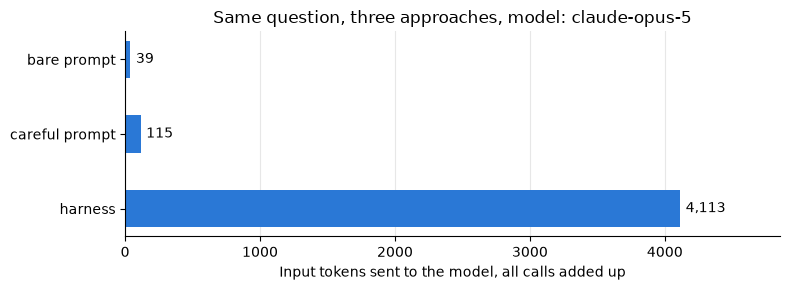

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(summary.index, summary["input tokens"], color="#2a78d6", height=0.5)
ax.bar_label(bars, labels=[f"{v:,}" for v in summary["input tokens"]], padding=4)
ax.set_xlim(0, summary["input tokens"].max() * 1.18)
ax.invert_yaxis()                                   # first approach at the top
ax.set_xlabel("Input tokens sent to the model, all calls added up")
ax.set_ylabel("")
ax.set_title(f"Same question, three approaches, model: {MAIN_MODEL}")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**How to read it:** each bar is the total number of input tokens one approach sent to the model across all its calls; longer is more expensive. The two prompt-only approaches make one call with almost no context. The harness makes several calls, and each one carries the tool descriptions plus every tool result gathered so far, which is where the tokens go.

Tokens are the currency of harness engineering. Everything in the next notebooks (context budgets, compaction, sub-agents, evals) is about spending them where they buy correctness, and nowhere else.

## 4. The SDK ships the loop

The loop you just wrote is so common that the SDK ships one. Two pieces:

- `beta_tool` wraps a Python function and generates the JSON description from its signature and docstring. The type hints become the schema; the `Args:` lines become the argument descriptions.
- `client.beta.messages.tool_runner(...)` is the loop: it calls the model, runs the tools it asks for, feeds the results back, and stops when the model stops asking. It is in beta in the Python SDK, which is why it lives under `client.beta`.

First, check that the generated description matches the one you wrote by hand.

In [13]:
from anthropic import beta_tool

sdk_tools = [beta_tool(list_files), beta_tool(read_file)]     # the same two functions, wrapped
print(json.dumps(sdk_tools[1].to_dict(), indent=2))

{
  "name": "read_file",
  "description": "Return the text of one file of the repository.\n\nCall it to check a fact in a file. Text files only; long files are cut at 20,000 characters.",
  "input_schema": {
    "additionalProperties": false,
    "properties": {
      "path": {
        "description": "Repository-relative path, for example README.md.",
        "title": "Path",
        "type": "string"
      }
    },
    "required": [
      "path"
    ],
    "type": "object"
  }
}


Same name, the same description (the decorator keeps the docstring's line break), same schema, plus two details the decorator adds: a `title` per argument and `additionalProperties: false`, which forbids arguments you did not declare. Now the loop in about ten lines. Each iteration of the `for` yields the model's message *before* the tools run; calling `generate_tool_call_response()` in the body runs the tools once and lets us keep a copy of the conversation, because the runner does not expose its own.

In [14]:
runner = client.beta.messages.tool_runner(
    model=MAIN_MODEL, max_tokens=2000, system=SYSTEM_TOOLS, tools=sdk_tools,
    messages=[{"role": "user", "content": QUESTION}],
    output_config={"effort": "medium"}, max_iterations=8,
)
runner_history, runner_usages = [{"role": "user", "content": QUESTION}], []
for message in runner:                                         # one iteration per model call
    runner_usages.append(record(message, MAIN_MODEL).usage)
    runner_history.append({"role": "assistant", "content": message.content})
    tool_reply = runner.generate_tool_call_response()          # runs the requested tools (once)
    if tool_reply is not None:
        runner_history.append(tool_reply)

runner_answer = text_of(message)
print(runner_answer)
print()
print("total:", usage_line(runner_usages, MAIN_MODEL))

**Python 3.12**, and the `execute` job's matrix runs **9 notebooks** (3 each from Modules 1, 2, and 3).

- Source: `.github/workflows/notebooks.yml` — both jobs use `actions/setup-python@v7` with `python-version: "3.12"`.
- Note: Module 5's 4 notebooks are run in a separate job (`module-5`) via a shell loop, not via the matrix, and only if the `ANTHROPIC_API_KEY` secret is set — so 13 notebooks total across the workflow.

total: 3 model call(s)   input 4,251 tokens   output 358 tokens   cost $0.0302


In the run recorded here the runner took the same route as your loop, in 3 model calls, and both answers give the fact. The messages the runner produced have exactly the shape your loop produced: a user question, then pairs of an assistant turn (thinking, maybe text, `tool_use` blocks) and a user turn made of `tool_result` blocks, and a final assistant turn with the answer.

In [15]:
def show_messages(messages):
    """One line per content block: who said it, what kind of block, and a glimpse of it."""
    for i, m in enumerate(messages):
        content = m["content"]
        if isinstance(content, str):
            print(f"{i:>2}. {m['role']:<9} text         {shorten(content, 80)}")
            continue
        for block in content:
            kind = block["type"] if isinstance(block, dict) else block.type
            if kind == "tool_use":
                detail = f"{block.name}({json.dumps(block.input)})"
            elif kind == "tool_result":
                detail = f"{len(block['content']):,} chars" + (" (error)" if block.get("is_error") else "")
            elif kind == "text":
                detail = shorten(block.text, 80)
            else:
                detail = "(no visible text)"                   # thinking blocks are summarised away by default
            print(f"{i:>2}. {m['role']:<9} {kind:<12} {detail}")


show_messages(runner_history)
print()
print("hand-written loop:  gives the fact =", gives_the_fact(harness_run["answer"]),
      "  names the file =", "notebooks.yml" in harness_run["answer"])
print("SDK tool runner:    gives the fact =", gives_the_fact(runner_answer),
      "  names the file =", "notebooks.yml" in runner_answer)

 0. user      text         Which Python version does this repository's notebook workflow use, and how ...
 1. assistant text         I'll explore the repository structure first.
 1. assistant tool_use     list_files({"folder": "."})
 1. assistant tool_use     list_files({"folder": ".github/workflows"})
 2. user      tool_result  288 chars
 2. user      tool_result  42 chars
 3. assistant tool_use     read_file({"path": ".github/workflows/notebooks.yml"})
 4. user      tool_result  2,809 chars
 5. assistant text         **Python 3.12**, and the `execute` job's matrix runs **9 notebooks** (3 each ...

hand-written loop:  gives the fact = True   names the file = True
SDK tool runner:    gives the fact = True   names the file = True


> **In plain words:** the loop you wrote in section 3 is what every harness does, from this notebook to Claude Code. The SDK's runner saves you the typing, and it is the right default for a small agent. But it decides nothing for you about *what surrounds the loop*: which tools to offer, what to refuse, when to stop, what to measure, how to test. That is the harness, and in Session 3 you will build a better one: a small `harness` package with a trace, a budget, hooks that run before every tool, and an eval suite.

## 5. The eight pieces of a harness

The source-code study of eleven coding agents (Barbaste et al., Jul 2026) and Anthropic's engineering posts converge on the same anatomy. We will use these eight pieces, in this order, for the rest of the module. You have already met four of them in this notebook.

| # | Piece | In plain words | In the car | Where you meet it in this module |
|---|---|---|---|---|
| 1 | **Model** | the engine, interchangeable behind one call: context in, next message out | engine | `client.messages.create(model=...)` and `client.models.retrieve` (this notebook); choosing by capability, cost and latency (Session 2) |
| 2 | **Context** | everything the model sees on one call: system prompt, history, tool results; a finite budget | dashboard and mirrors | `system`, `messages` and `usage.input_tokens` (this notebook); `count_tokens`, compaction, notes outside the window (Session 2) |
| 3 | **Tools** | functions the model may call by name with JSON arguments; the harness runs them | trailer hitch | raw tool dicts, `tool_use`, `tool_result`, `beta_tool` (this notebook); tool design and MCP servers (Session 2 and its Claude Code lab) |
| 4 | **Skills** | folders of instructions loaded only when a task needs them | glovebox manuals | `SKILL.md` folders, measured on the real tokenizer (Session 2 notebook and lab) |
| 5 | **The loop** | ask, act, feed back, repeat, with stop conditions | steering wheel and pedals | `run_agent` and `tool_runner` (this notebook); `Agent.run` in the `harness` package (Session 3) |
| 6 | **Guardrails and permissions** | checks your code runs outside the model: before a tool runs, after an answer | brakes, seatbelts, airbags | the `.env` refusal inside `read_file` (this notebook); hooks and risk levels in `harness` (Session 3); Claude Code hooks and permission modes (Session 4 lab) |
| 7 | **Orchestration** | workflows when the path is known, agents when it is not; sub-agents and teams for parallel work | the GPS route; a convoy | the five workflow patterns (Session 3); sub-agents, teams and handoffs (Session 4 and its lab) |
| 8 | **Evals and observability** | a record of every step, token accounting, and a test suite of tasks with graders | dashboard | `usage`, the cost table and the ledger (this notebook); traces, `evals/cases.yaml` and the GitHub Actions eval job (Session 3) |

## 6. Key takeaways

- **Prompt engineering has a ceiling.** A prompt changes what the model says, not what it can do. Every advance after 2022 (ReAct, function calling, MCP, context engineering, skills, evals) added something around the model.
- **Agent = model + harness.** The harness is the runtime that couples the model to the world: a loop, tools, context management, guardrails, orchestration and observability. In plain words: the model is the engine; the harness is the rest of the car.
- **The smallest harness is four parts:** a list of messages, a model behind one call, tools the model can only ask for, and a loop with a stop condition. You wrote one in about forty lines on the raw SDK, and the SDK's `tool_runner` does the same in ten.
- **Same model, three answers.** Bare prompt and careful prompt: no checkable fact, because no file was opened. Harness: the fact and the file. The model never changed.
- **Tokens are the cost of correctness.** The harness spent more input tokens than the prompts because every call carried the evidence gathered so far. `usage` shows exactly where they went, and that is what lets you decide whether they were worth it.
- **Guardrails live in your code.** The refusal to read `.env` did not depend on the model's good will; it ran before the file was touched. Session 3 turns this into hooks and permissions.
- **Eight pieces, one checklist.** Model, context, tools, skills, loop, guardrails, orchestration, evals and observability. Each gets its own treatment in the next three notebooks.

## 7. Practice exercises

Try these yourself before peeking at the solutions. All of them reuse `run_agent` from section 3.

**Exercise 1 - A third tool.** Write `count_lines(path)` that returns the number of lines of one repository file, add its JSON description to a copy of `TOOLS` and its function to a copy of `FUNCTIONS`, and ask: *How many lines does CONTRIBUTING.md have?* Does the model use the new tool, or does it read the whole file and count? Check the number against a direct call.

**Exercise 2 - Cut the loop short.** Run `run_agent(QUESTION, max_turns=1)`. What does the model ask for, what does the loop do with it, and what comes back as the answer? Read `stopped_because`.

**Exercise 3 - A trap question.** Ask the harness *How many students took this course?* The repository does not contain that. Read what the model does with the tools and what it finally says.

**Exercise 4 - Another engine.** Run `run_agent(QUESTION, model="claude-sonnet-5")` and compare model calls, tool calls, tokens and cost with the `claude-opus-5` run in `harness_run`. Same harness, same effort setting, different engine.

## 8. Solutions

**Solution 1 - A third tool.** The tool is three lines; the JSON description is what teaches the model when to prefer it over `read_file`. Whether the model takes the shortcut or reads the whole file is its decision, and it is worth watching, because a tool nobody calls is just tokens in the prompt. In the run recorded here it called `count_lines` straight away, and in the same turn also listed the root folder, which it did not need; the count matched the direct call (49 lines) and the whole exercise took 2 model calls.

In [16]:
def count_lines(path: str) -> str:
    """Count the lines of one text file of the repository."""
    return str(len(safe_path(path).read_text(encoding="utf-8").splitlines()))


COUNT_LINES_TOOL = {
    "name": "count_lines",
    "description": ("Count the lines of one text file of the repository. Call it when a question asks how long "
                    "a file is, instead of reading the whole file."),
    "input_schema": {
        "type": "object",
        "properties": {"path": {"type": "string", "description": "Repository-relative path, for example README.md."}},
        "required": ["path"],
    },
}

three_tools = [*TOOLS, COUNT_LINES_TOOL]
three_functions = {**FUNCTIONS, "count_lines": count_lines}

ex1 = run_agent("How many lines does CONTRIBUTING.md have?", tools=three_tools, functions=three_functions)
print()
print("ANSWER:", ex1["answer"])
print("direct call count_lines('CONTRIBUTING.md') ->", count_lines("CONTRIBUTING.md"))
print("usage:", usage_line(ex1["usages"], MAIN_MODEL))

turn 1  tool_use     count_lines({"path": "CONTRIBUTING.md"})
turn 1  tool_result  2 chars: 49
turn 1  tool_use     list_files({"folder": "."})
turn 1  tool_result  288 chars: .github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - Descriptive ...



ANSWER: CONTRIBUTING.md at the repository root has **49 lines**.
direct call count_lines('CONTRIBUTING.md') -> 49
usage: 2 model call(s)   input 1,931 tokens   output 129 tokens   cost $0.0129


**Solution 2 - Cut the loop short.** With one turn the model can ask for tools, the loop runs them, and then there is no second call to read the results. Whatever text came back with the tool request is all you get: at best a sentence announcing a plan, never the fact. `stopped_because` says why. In the run recorded here the model asked for 2 listings and announced its plan in one sentence; that sentence is the whole "answer". The tools ran and their results were paid for, but the model never saw them: a cut costs you the last step, not the whole run.

In [17]:
ex2 = run_agent(QUESTION, max_turns=1)
print()
print("answer:         ", repr(ex2["answer"]))
print("stopped because:", ex2["stopped_because"])
print("model calls:    ", ex2["turns"], "  tool calls:", ex2["tool_calls"])
print("usage:", usage_line(ex2["usages"], MAIN_MODEL))

turn 1  tool_use     list_files({"folder": "."})
turn 1  tool_result  288 chars: .github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - Descriptive ...
turn 1  tool_use     list_files({"folder": ".github/workflows"})
turn 1  tool_result  42 chars: ci.yml harness.yml notebooks.yml pages.yml

answer:          "I'll explore the repository structure first."
stopped because: max_turns
model calls:     1   tool calls: 2
usage: 1 model call(s)   input 702 tokens   output 111 tokens   cost $0.0063


**Solution 3 - A trap question.** The system prompt tells the model to say so when the repository does not contain the answer. Read the route: how many files it opens before giving up tells you how expensive "I do not know" can be. In the run recorded here the model listed the root, read the whole README (16,973 characters, the largest tool result in this notebook) and answered after 3 model calls; at $0.0562 it was the most expensive single run in the notebook, and it also flagged the number it suspected the question was confusing (the Titanic passenger count). That cost is and that is why Session 3 asks for a structured `found: false` instead of a sentence, and why an eval set always contains trap questions.

In [18]:
ex3 = run_agent("How many students took this course?")
print()
print("ANSWER:", ex3["answer"])
print("stopped because:", ex3["stopped_because"], "  model calls:", ex3["turns"], "  tool calls:", ex3["tool_calls"])
print("usage:", usage_line(ex3["usages"], MAIN_MODEL))

turn 1  tool_use     list_files({"folder": "."})
turn 1  tool_result  288 chars: .github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - Descriptive ...


turn 2  tool_use     read_file({"path": "README.md"})
turn 2  tool_result  16,973 chars: # Fontys Tech Exercises [![CI](https://github.com/maglionejm/fontys-tech- ...



ANSWER: The repository doesn't contain that information. Nothing in it reports enrollment or attendance figures — it is a course materials repo (notebooks, decks, a docs site), not a record of participants.

One caveat worth flagging, in case it's the source of the question: the README does prominently feature the number **891**, but that's the number of rows in the Titanic passenger dataset used throughout Modules 1–3 ("891 passengers of the Titanic, twelve columns, 342 survivors"), not a count of students ([README.md](README.md)).

The only student-facing counts in the repo are course-content ones, also from `README.md`: four modules, thirteen notebooks, eight teaching decks, and two Claude Code labs.
stopped because: done   model calls: 3   tool calls: 2
usage: 3 model call(s)   input 9,143 tokens   output 419 tokens   cost $0.0562


**Solution 4 - Another engine.** Nothing in `run_agent` names the model; it is an argument. The comparison below puts the two engines side by side on the same question with the same tools, prompt and effort. Two things can differ: the route (how many calls and tool calls each model needed, which drives the input tokens) and the price per token. Compare the cost column, not only the counts. In the run recorded here `claude-sonnet-5` skipped the root listing and went straight to `.github/workflows`, so it made 2 tool calls to `claude-opus-5`'s 3, both gave the fact, and the Sonnet run cost $0.0106 against $0.0293.

In [19]:
WORKER_MODEL = "claude-sonnet-5"
sonnet_run = run_agent(QUESTION, model=WORKER_MODEL)
print()
print("ANSWER:", sonnet_run["answer"])
print()
comparison = pd.DataFrame([summary_row(MAIN_MODEL, harness_run),
                           summary_row(WORKER_MODEL, sonnet_run)]).set_index("approach")
comparison.index.name = "model"
comparison

turn 1  tool_use     list_files({"folder": ".github/workflows"})
turn 1  tool_result  42 chars: ci.yml harness.yml notebooks.yml pages.yml


turn 2  tool_use     read_file({"path": ".github/workflows/notebooks.yml"})
turn 2  tool_result  2,809 chars: name: Execute notebooks # Every notebook is run top to bottom in a clean environment, ...



ANSWER: The notebook workflow (`.github/workflows/notebooks.yml`) uses **Python 3.12** (set via `actions/setup-python@v7` with `python-version: "3.12"`).

The main matrix (`execute` job) runs **9 notebooks** (3 from M1, 3 from M2, 3 from M3). There is also a separate `module-5` job (not part of the matrix strategy) that sequentially runs 4 additional Module 5 notebooks when the `ANTHROPIC_API_KEY` secret is available, but those aren't executed via the matrix mechanism.



,model calls,tool calls,input tokens,output tokens,cost (USD),gives the fact,names the file
model,,,,,,,
claude-opus-5,3,3,4113,350,0.0293,True,True
claude-sonnet-5,3,2,3783,307,0.0106,True,True


## 9. The bill

Every call in this notebook went through `record`, so the ledger holds every receipt. This is the whole notebook's spend in the run recorded here: 17 model calls and $0.1720.

In [20]:
bill = pd.DataFrame([{"model": model,
                      "input tokens": u.input_tokens,
                      "output tokens": u.output_tokens,
                      "cost (USD)": cost_usd(u, model)} for model, u in LEDGER])
totals = bill.groupby("model").agg(calls=("cost (USD)", "size"), input_tokens=("input tokens", "sum"),
                                   output_tokens=("output tokens", "sum"), cost_usd=("cost (USD)", "sum"))
print(totals.round(4).to_string())
print()
print(f"Total: {len(bill)} model calls, {bill['input tokens'].sum():,} input tokens, "
      f"{bill['output tokens'].sum():,} output tokens, ${bill['cost (USD)'].sum():.4f}")

                 calls  input_tokens  output_tokens  cost_usd
model                                                        
claude-opus-5       14         20294           2397    0.1614
claude-sonnet-5      3          3783            307    0.0106

Total: 17 model calls, 24,077 input tokens, 2,704 output tokens, $0.1720
